# Model Exploration and Testing

## Step 1: Data Load

In [63]:
import pandas as pd
import os

def reduce_twitter_dataset(input_file, output_file, sample_size=50000):
    """
    Reduces the Sentiment140 dataset while maintaining class balance.
    Columns: 0: target, 1: id, 2: date, 3: flag, 4: user, 5: text
    """

    if os.path.exists(output_file):
        print(f"Data already processed and saved at {output_file}")
        return

    cols = ["sentiment", "id", "date", "query", "user", "text"]

    print("Reading dataset in chunks...")
    # Using 'latin-1' encoding as this dataset often has special characters
    chunks = pd.read_csv(input_file, encoding='latin-1', header=None, names=cols, chunksize=100000)

    df_list = []
    for chunk in chunks:
        # Keep only necessary columns to save memory immediately
        df_list.append(chunk[['sentiment', 'text']])

    full_df = pd.concat(df_list)

    # Stratified sampling: Ensure 50/50 split of Positive (4) and Negative (0)
    # The dataset uses 0=negative, 2=neutral (rare), 4=positive
    negative_tweets = full_df[full_df['sentiment'] == 0].sample(n=sample_size//2, random_state=42)
    positive_tweets = full_df[full_df['sentiment'] == 4].sample(n=sample_size//2, random_state=42)

    reduced_df = pd.concat([negative_tweets, positive_tweets]).sample(frac=1).reset_index(drop=True)

    reduced_df.to_csv(output_file, index=False)
    print(f"Success! Reduced file saved to {output_file} with {len(reduced_df)} rows.")

In [64]:
init_data_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/twitter_data.csv"
reduced_data_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/reduced_twitter_data.csv"

In [65]:
reduce_twitter_dataset(init_data_path,reduced_data_path)

Data already processed and saved at /home/water/Grad School/DSE6212/Project/data/reduced_twitter_data.csv


In [66]:
df = pd.read_csv(reduced_data_path)

## Step 2: Preprocessing

In [67]:
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import re
import emoji

nltk.download("stopwords")
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /home/water/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/water/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/water/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [68]:
def preprocess(text:str, stemmer:PorterStemmer|SnowballStemmer|None=None, lem:WordNetLemmatizer|None=None):
    assert not (stemmer is not None and lem is not None)

    # Lowercase
    text = text.lower()
    #convert emojis
    text = emoji.demojize(text, delimiters=("",""), language='alias')
    # Remove handles
    text = re.sub(r'\B@\S+','',text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stop words
    tokens = [token for token in tokens if token not in set(stopwords.words('english'))]

    # Stemming
    if stemmer:
        tokens = [stemmer.stem(token) for token in tokens]
    elif lem:
        tokens = [lem.lemmatize(token) for token in tokens]

    return " ".join(tokens)

### Step 3: Vectorization

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer

#### TF-IDF

In [70]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform([preprocess(text, lem=WordNetLemmatizer()) for text in df["text"].values])

print("\nTF-IDF Shape:", tfidf_matrix.shape)


TF-IDF Shape: (50000, 5000)


In [71]:
import numpy as np

In [72]:
# negative = 0, positive = 1
df['senitment'] = df['sentiment'].replace(4,1)

y = np.array(df['senitment'])
y

array([0, 0, 0, ..., 0, 1, 1], shape=(50000,))

### Step 4: Model Training

In [73]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [74]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split([preprocess(text, lem=WordNetLemmatizer()) for text in df["text"].values], y, test_size=0.3, random_state=42)

#### TF-IDF

In [75]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw)

In [76]:
svm_classifier_tfidf = LinearSVC(dual=False, max_iter=10000, random_state=42)
fit_svm_classifier_tfidf = svm_classifier_tfidf.fit(X_train_tfidf, y_train)

In [77]:
y_pred_tfidf = svm_classifier_tfidf.predict(X_test_tfidf)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(f"Model Accuracy: {accuracy_tfidf * 100:.2f}%")

Model Accuracy: 74.05%


In [78]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_score
import matplotlib.pyplot as plt

In [79]:
class ModelEvaluator():
    def __init__(self, fit_model=None, pipe=None):
        self.model = fit_model
        self.pipe = pipe
    
    def eval_model(self, X_test, y_test, labels):
        assert self.model is not None
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.model.predict(X_test)

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred >= 0.5:
                self.reclassified_predictions.append(1)
            else:
                self.reclassified_predictions.append(0)

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def eval_pipe(self, X_test:list[str], y_test:list[int], labels):
        assert self.pipe is not None
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.pipe(X_test)

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred['label']=='LABEL_0':
                self.reclassified_predictions.append(0)
            else:
                self.reclassified_predictions.append(1)
    
        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_metrics(self):
        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(self.novel_y, self.reclassified_predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(self.novel_y, self.reclassified_predictions)

        self.accuracy = f'{accuracy_score(self.novel_y, self.reclassified_predictions)*100:.2f}%'

        # Compute recall
        self.recall = self.confusion_matrix['true_positive'] / (self.confusion_matrix['true_positive'] + self.confusion_matrix['false_negative'])

        # Compute precision
        self.precision = precision_score(self.novel_y, self.reclassified_predictions)

        # Compute F1-Score
        self.f1_score = f'{(2*self.precision*self.recall)/(self.precision+self.recall):.2f}'

        print(f'\nAccuracy: {self.accuracy}')
        print(f'\nRecall: {self.recall}')
        print(f'\nPrecision: {self.precision}')
        print(f'\nF1-Score: {self.f1_score}')

#### TF-IDF Evaluation

Number of positive Predictions: 7656
Number of negative Predictions: 7344
Percent positive Predictions: 51.04
Percent negative Predictions: 48.96

Accuracy: 74.05%

Recall: 0.749271523178808

Precision: 0.7388975966562173

F1-Score: 0.74


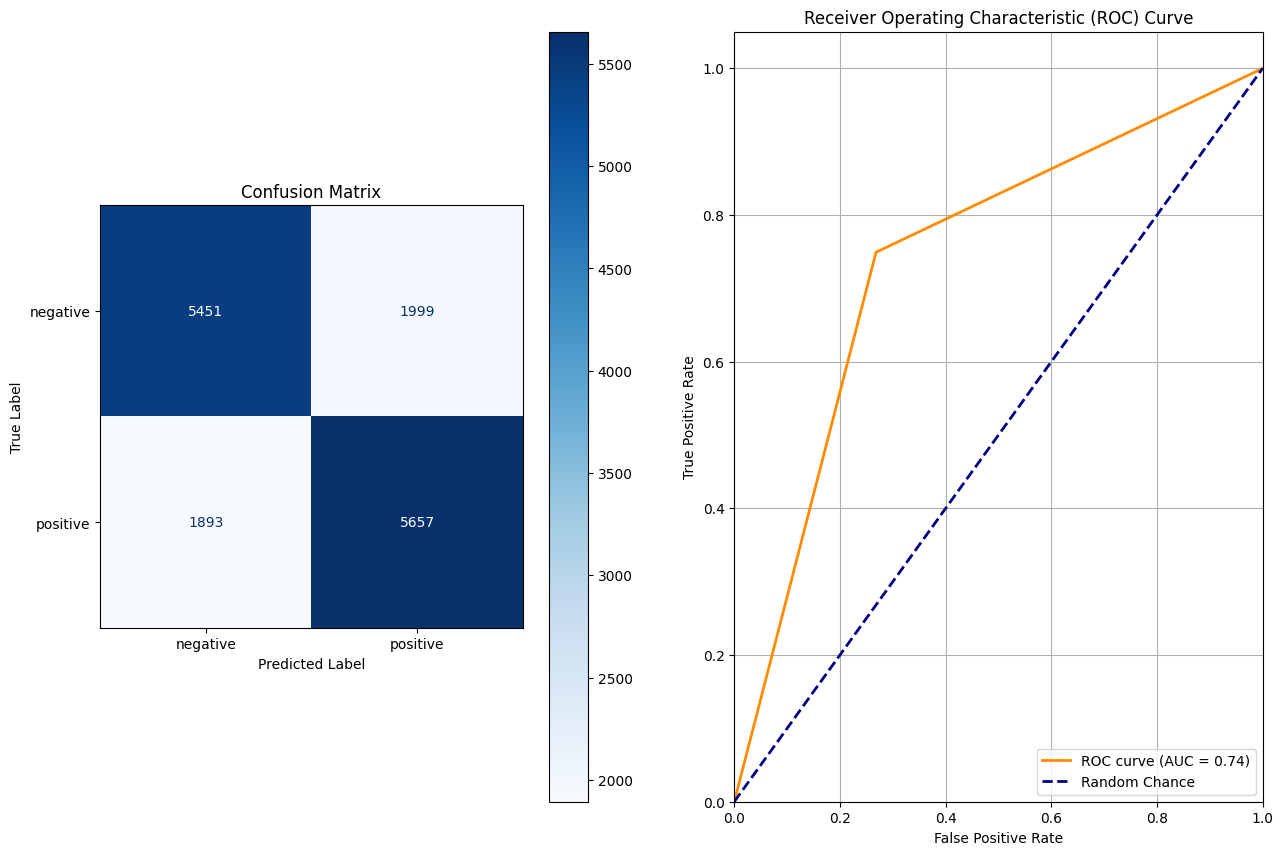

In [80]:
labels = ['negative', 'positive']

tfidf_evaluator = ModelEvaluator(fit_svm_classifier_tfidf)
tfidf_evaluator.eval_model(X_test_tfidf, y_test, labels)

### Step 5: Advanced Model Training

In [81]:
# Load model directly
import torch
from transformers import AutoTokenizer, TextClassificationPipeline, BertForSequenceClassification

checkpoint = 'google-bert/bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = BertForSequenceClassification.from_pretrained(checkpoint)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 921.77it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSI

In [82]:
# Store the device
device = "cuda" if torch.cuda.is_available() else "cpu"

In [83]:
import json

# Store the data in separate text files to be read in by the datasets package
X_train_raw, X_test_raw, y_train, y_test = train_test_split([text for text in df["text"].values], y, test_size=0.3, random_state=42)

train_data = {"type": "train",
            "data":[]
            }

test_data = {
            "type": "test",
            "data":[]
            }

for i in range(len(X_train_raw)):
    train_data["data"].append(
        {
            "Text":X_train_raw[i],
            "Sentiment":int(y_train[i])
    })

for i in range(len(X_test_raw)):
    test_data["data"].append(
        {
            "Text":X_test_raw[i],
            "Sentiment":int(y_test[i])
    })

In [84]:
# Save Data
train_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/train.json"
test_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/test.json"

with open(train_path, 'w+') as f:
    json.dump(train_data, f)

with open(test_path, 'w+') as f:
    json.dump(test_data, f)

In [85]:
from datasets import load_dataset

# Load from CSV
dataset = load_dataset("json", data_files={"train": train_path, "test": test_path}, field="data")


Generating train split: 35000 examples [00:00, 541418.08 examples/s]
Generating test split: 15000 examples [00:00, 674180.88 examples/s]


In [86]:
input_max_len = 512

def preprocess_function(examples):
    # Category A Blanks: Define truncation and padding strategies
    model_inputs = tokenizer(examples["Text"],
                             max_length=input_max_len, # Choose 512 for articles
                             truncation=True,)

    # We use a list comprehension to iterate through the batch of labels
    model_inputs["labels"] = examples["Sentiment"]

    return model_inputs

In [87]:
train_data = dataset['train'].map(preprocess_function, batched=True)
test_data = dataset['test'].map(preprocess_function, batched=True)

Map: 100%|██████████| 15000/15000 [00:00<00:00, 19851.57 examples/s]


In [ ]:
from transformers import TrainingArguments, DataCollatorWithPadding, Trainer

def train(model, tokenizer, train_data, test_data):
    counter = 0
    while 1:
        if os.path.exists(f"./results_{counter}"):
            counter+=1
        else:
            output_dir = f"./results_{counter}"
            break

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=5e-5,        # Hint: 5e-5 is standard for BART
        num_train_epochs=3,     # Hint: 3 to 5 is sufficient
        per_device_train_batch_size=8,
        fp16=torch.cuda.is_available(),
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer,
        padding="longest",
        max_length=input_max_len
    )

    # Category B Scaffold: Initialization of the Trainer API
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_data,
        eval_dataset=test_data,
        data_collator=data_collator
    )

    # Train the model
    trainer.train()

In [89]:
from transformers import pipeline

ft_model_checkpoint = 'results_0/checkpoint-17500'

ft_tokenizer = AutoTokenizer.from_pretrained(ft_model_checkpoint)
ft_model = BertForSequenceClassification.from_pretrained(ft_model_checkpoint)

pipe = pipeline(task="sentiment-analysis", model=ft_model, tokenizer=ft_tokenizer)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 934.54it/s, Materializing param=classifier.weight]                                      


In [90]:
# Load novel data
def get_novel_data(input_file, sample_size=10000):
    """
    Reduces the Sentiment140 dataset while maintaining class balance.
    Columns: 0: target, 1: id, 2: date, 3: flag, 4: user, 5: text
    """

    cols = ["sentiment", "id", "date", "query", "user", "text"]

    print("Reading dataset in chunks...")
    # Using 'latin-1' encoding as this dataset often has special characters
    chunks = pd.read_csv(input_file, encoding='latin-1', header=None, names=cols, chunksize=100000)

    df_list = []
    for chunk in chunks:
        # Keep only necessary columns to save memory immediately
        df_list.append(chunk[['sentiment', 'text']])

    full_df = pd.concat(df_list)

    # Stratified sampling: Ensure 50/50 split of Positive (4) and Negative (0)
    # The dataset uses 0=negative, 2=neutral (rare), 4=positive
    negative_tweets = full_df[full_df['sentiment'] == 0].sample(n=sample_size//2, random_state=85)
    positive_tweets = full_df[full_df['sentiment'] == 4].sample(n=sample_size//2, random_state=85)

    reduced_df = pd.concat([negative_tweets, positive_tweets]).sample(frac=1).reset_index(drop=True)

    # Select only rows not in the training data
    uniuque_rows = reduced_df[~df['text'].isin(reduced_df['text'])]

    return uniuque_rows

In [91]:
val_data = get_novel_data(f"{'/'.join(os.getcwd().split('/')[:-1])}/data/original_twitter_data.csv")

Reading dataset in chunks...


/tmp/ipykernel_46340/2901066956.py:29: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  uniuque_rows = reduced_df[~df['text'].isin(reduced_df['text'])]


In [92]:
pipe_evaluator = ModelEvaluator(pipe=pipe)

In [93]:
val_data['senitment'] = val_data['sentiment'].replace(4,1)

y_val = np.array(val_data['senitment'])

Number of Positive Predictions: 4759
Number of Negative Predictions: 5166
Percent Positive Predictions: 47.949622166246854
Percent Negative Predictions: 52.050377833753146

Accuracy: 82.68%

Recall: 0.8060813532017721

Precision: 0.8411430972893466

F1-Score: 0.82


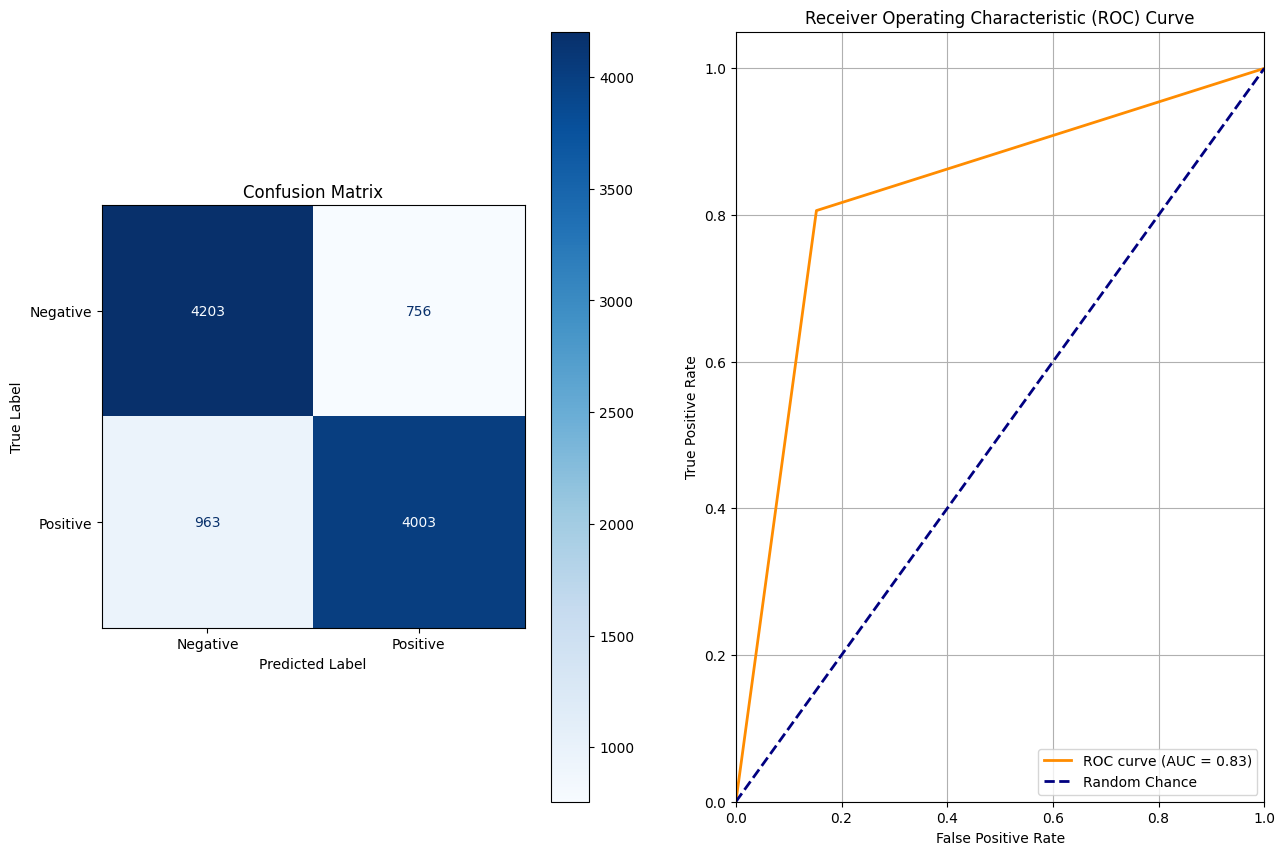

In [94]:
labels = ["Negative", "Positive"]
pipe_evaluator.eval_pipe(X_test=list(val_data['text'].values), y_test=y_val, labels=labels)

In [95]:
# Fine Tune a bit more
checkpoint = 'results_0/checkpoint-17500'
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = BertForSequenceClassification.from_pretrained(checkpoint)

train(model, tokenizer, train_data, test_data)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 972.34it/s, Materializing param=classifier.weight]                                      


Step,Training Loss
500,0.221486
1000,0.186699
1500,0.219270
2000,0.222183
2500,0.216267
3000,0.261972
3500,0.240069
4000,0.253112
4500,0.239336
5000,0.148630


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.55it/s]


In [99]:
model_1_checkpoint = 'results_1/checkpoint-12000'

tokenizer_1 = AutoTokenizer.from_pretrained(model_1_checkpoint)
model_1 = BertForSequenceClassification.from_pretrained(model_1_checkpoint)

pipe_1 = pipeline(task="sentiment-analysis", model=model_1, tokenizer=tokenizer_1)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 902.92it/s, Materializing param=classifier.weight]                                      


Number of Positive Predictions: 4824
Number of Negative Predictions: 5101
Percent Positive Predictions: 48.604534005037785
Percent Negative Predictions: 51.39546599496222

Accuracy: 82.23%

Recall: 0.8080950463149416

Precision: 0.831882255389718

F1-Score: 0.82


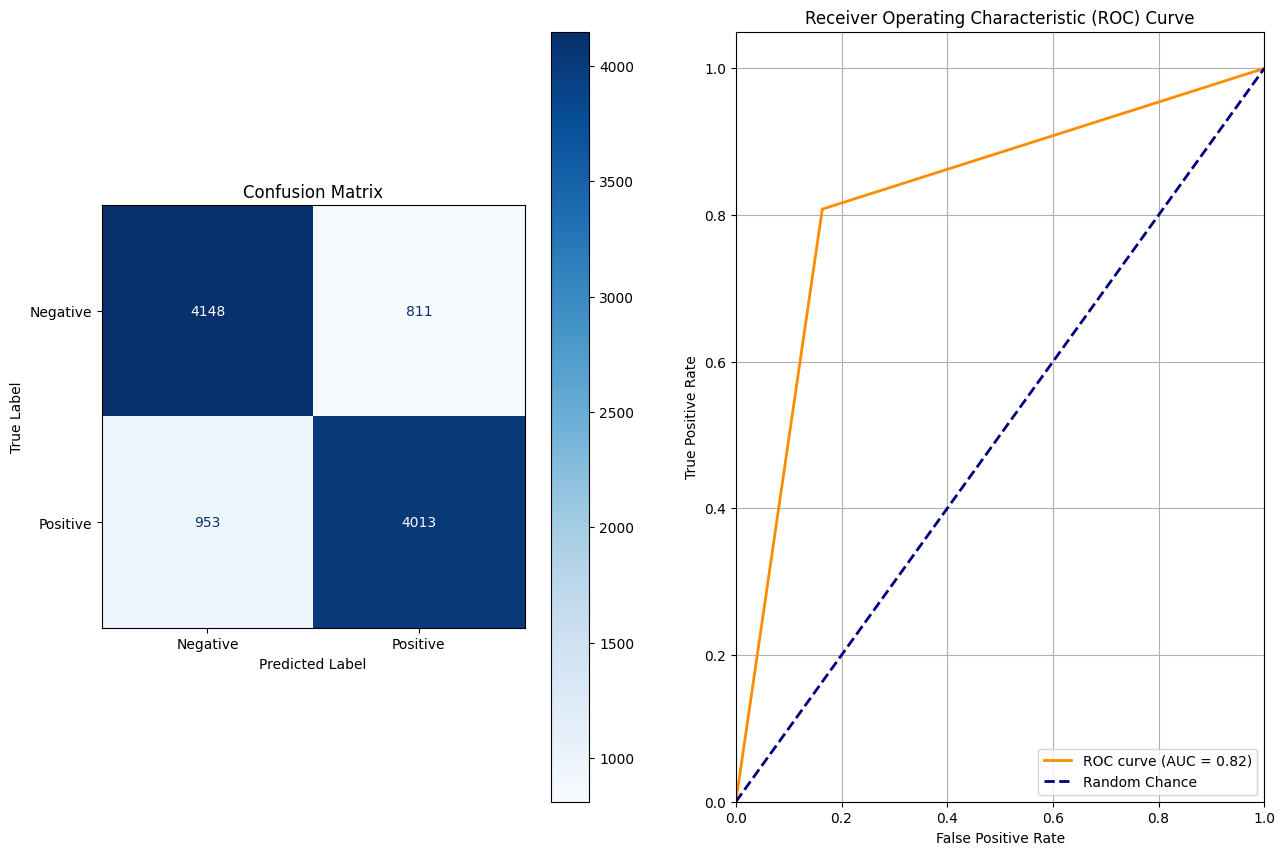

In [100]:
pipe_evaluator_1 = ModelEvaluator(pipe=pipe_1)
pipe_evaluator_1.eval_pipe(X_test=list(val_data['text'].values), y_test=y_val, labels=labels)